# Preprocessing

A reconstruction never sees the whole video. The `preproc` stage takes the video in, measures
every frame for blur, exposure and camera motion, and writes those measurements to a quality
report. It then picks a subset of frames from the ones that pass a quality check and saves them
as the keyframe store, a folder of PNGs that every later stage reads.

In [1]:
from IPython.display import Image, display

from collab_splats.preproc.frames import frame_idx_from_path, frame_paths, read_frames
from collab_splats.preproc.qa import load_video_quality
from collab_splats.preproc.sampling import (
    filter_frame_quality,
    sample_fps,
    sample_optical_flow,
    sample_uniform,
)
from collab_splats.preproc.viz import (
    plot_correlation,
    plot_frame_extremes,
    plot_frame_grid,
    plot_motion,
    plot_photometric,
    plot_selection,
)

%run ../tutorial.py

scene = tutorial_scene("preproc")

fps=2.000 wanted 199 frames, outside [min_frames=None, max_frames=96]; re-spread to 96 frames over the whole video (effective 0.964 fps)


## 1. Capture quality

Before any frame is chosen, the stage measures the clip. Each frame gets photometry (blur,
exposure, clipped pixels) and each pair of nearby frames gets motion (translation, parallax,
feature match count). The stage saved this as `video_quality_report.json` next to the keyframe
store, and `load_video_quality` reads that file back without decoding the video again.

The report only records measurements. It holds no thresholds and does not mark any frame as good
or bad; that decision happens in section 2.

In [2]:
# The preproc stage writes its report next to the images/ folder
report_path = scene.images_dir.parent / "video_quality_report.json"
report = load_video_quality(VIDEO_PATH, report_path)
print("frame columns:", sorted(report["frames"]))
print("pair columns:", sorted(report["pairs"]))

# Source frame index of every keyframe the stage kept
stored = frame_paths(scene.images_dir)
kept = [frame_idx_from_path(p) for p in stored]

# The plotters write PNGs; keep them in this page's scratch folder
plots_dir = work_dir("preprocessing")

frame columns: ['blur', 'clipped_high_frac', 'clipped_low_frac', 'exposure_mean', 'exposure_median', 'exposure_std', 'frame_idx', 'laplacian']
pair columns: ['frame_idx_a', 'frame_idx_b', 'n_matches', 'parallax', 'translation_px']


Photometry over time, with the frames the stage kept marked. Each plotter writes a PNG and
returns its path.

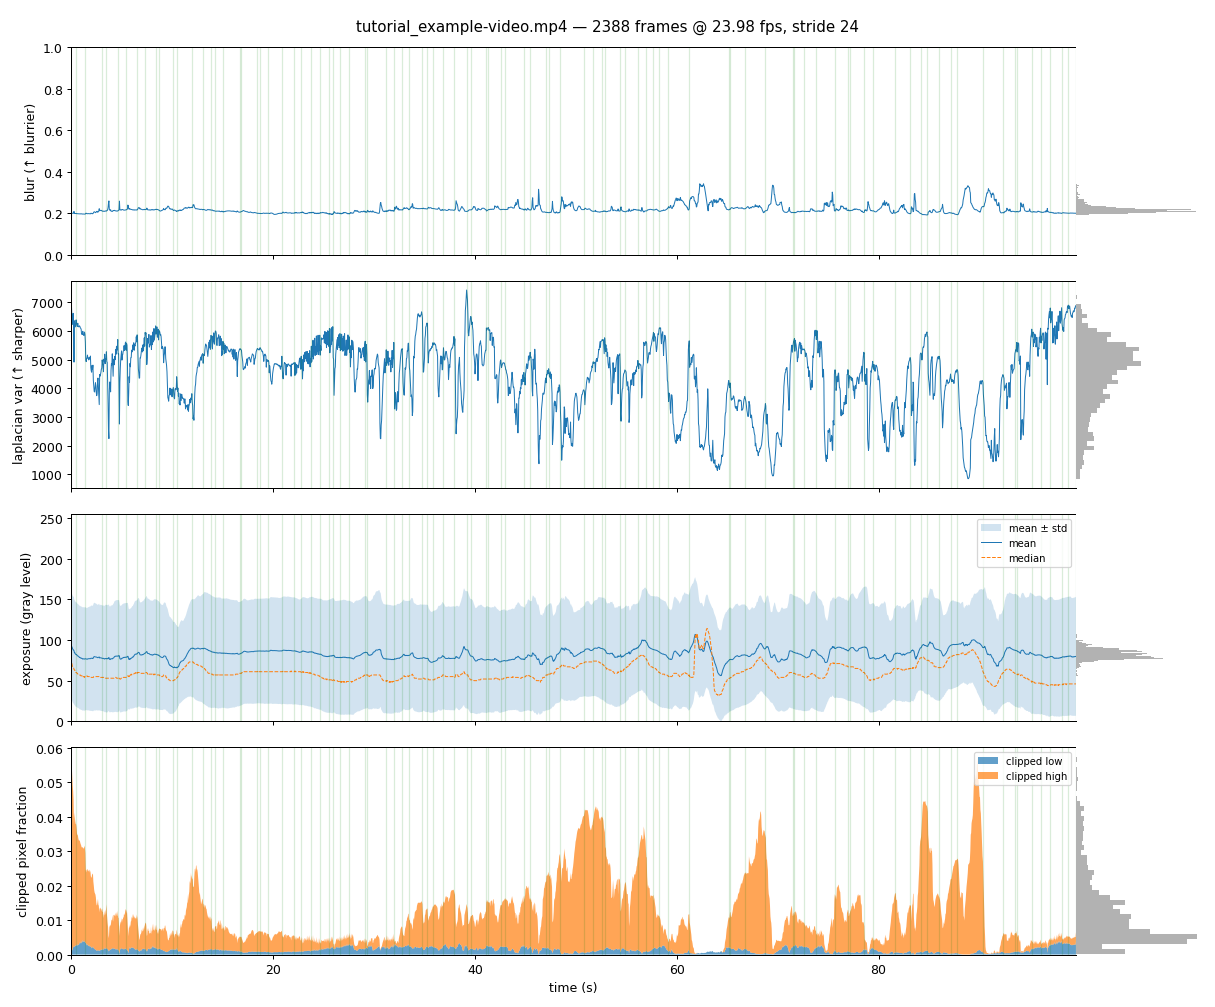

In [3]:
photometric_png = plot_photometric(report, plots_dir, selected=kept)
Image(filename=photometric_png)

Look for dips in sharpness and spikes in clipped pixels, and check that the kept frames avoid
them.

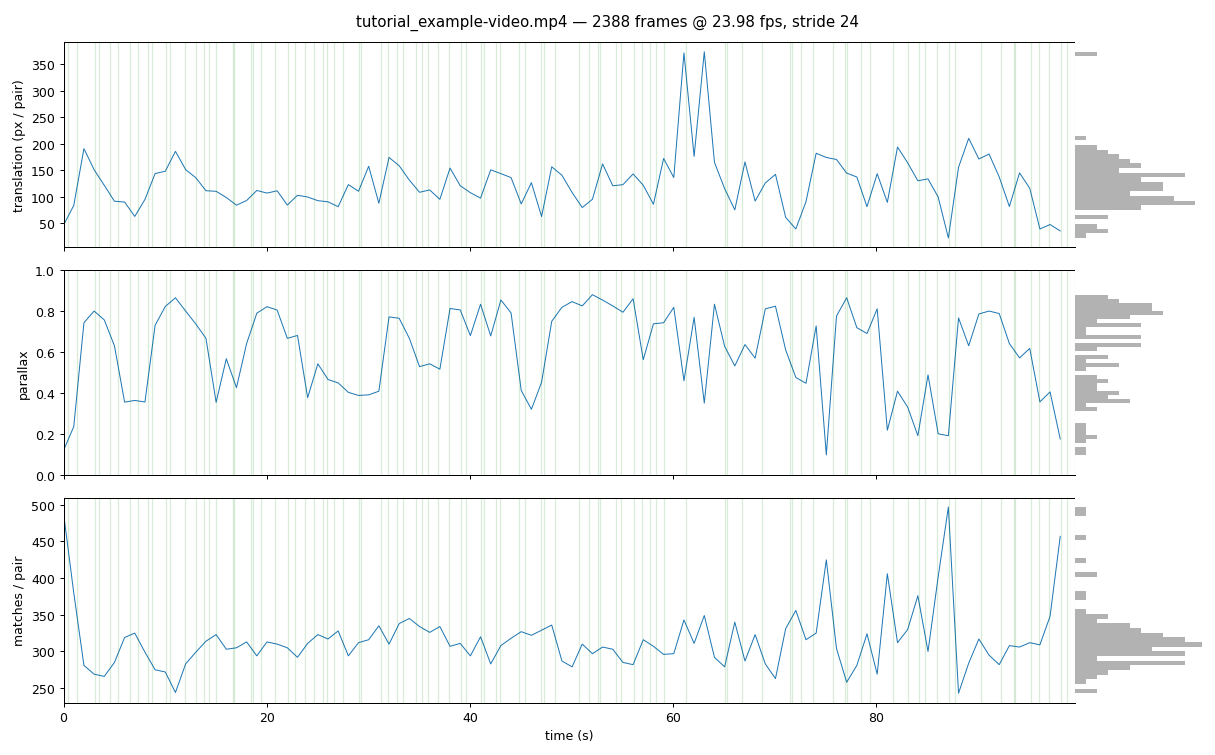

In [4]:
motion_png = plot_motion(report, plots_dir, selected=kept)
if motion_png is not None:
    motion_image = Image(filename=motion_png)
    display(motion_image)

Motion per frame pair: how far the camera moved and how well the pair's features agreed.
Stretches with few matches are where the camera turned fast or the view lost texture.

Blur is measured per frame and translation per pair. `plot_correlation` reads the blur of each
pair's first frame so the two columns line up sample for sample.

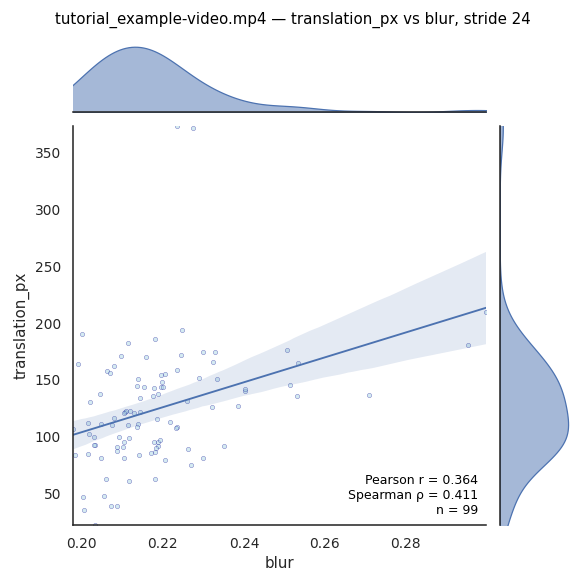

In [5]:
correlation_png = plot_correlation(report, "blur", "translation_px", plots_dir)
if correlation_png is not None:
    correlation_image = Image(filename=correlation_png)
    display(correlation_image)

A positive slope means fast camera motion blurs frames; the strength of the correlation shows
how much on this clip.

To see what the blur number means on real footage, `plot_frame_extremes` decodes the sharpest
and blurriest frames. Only these four frames are decoded.

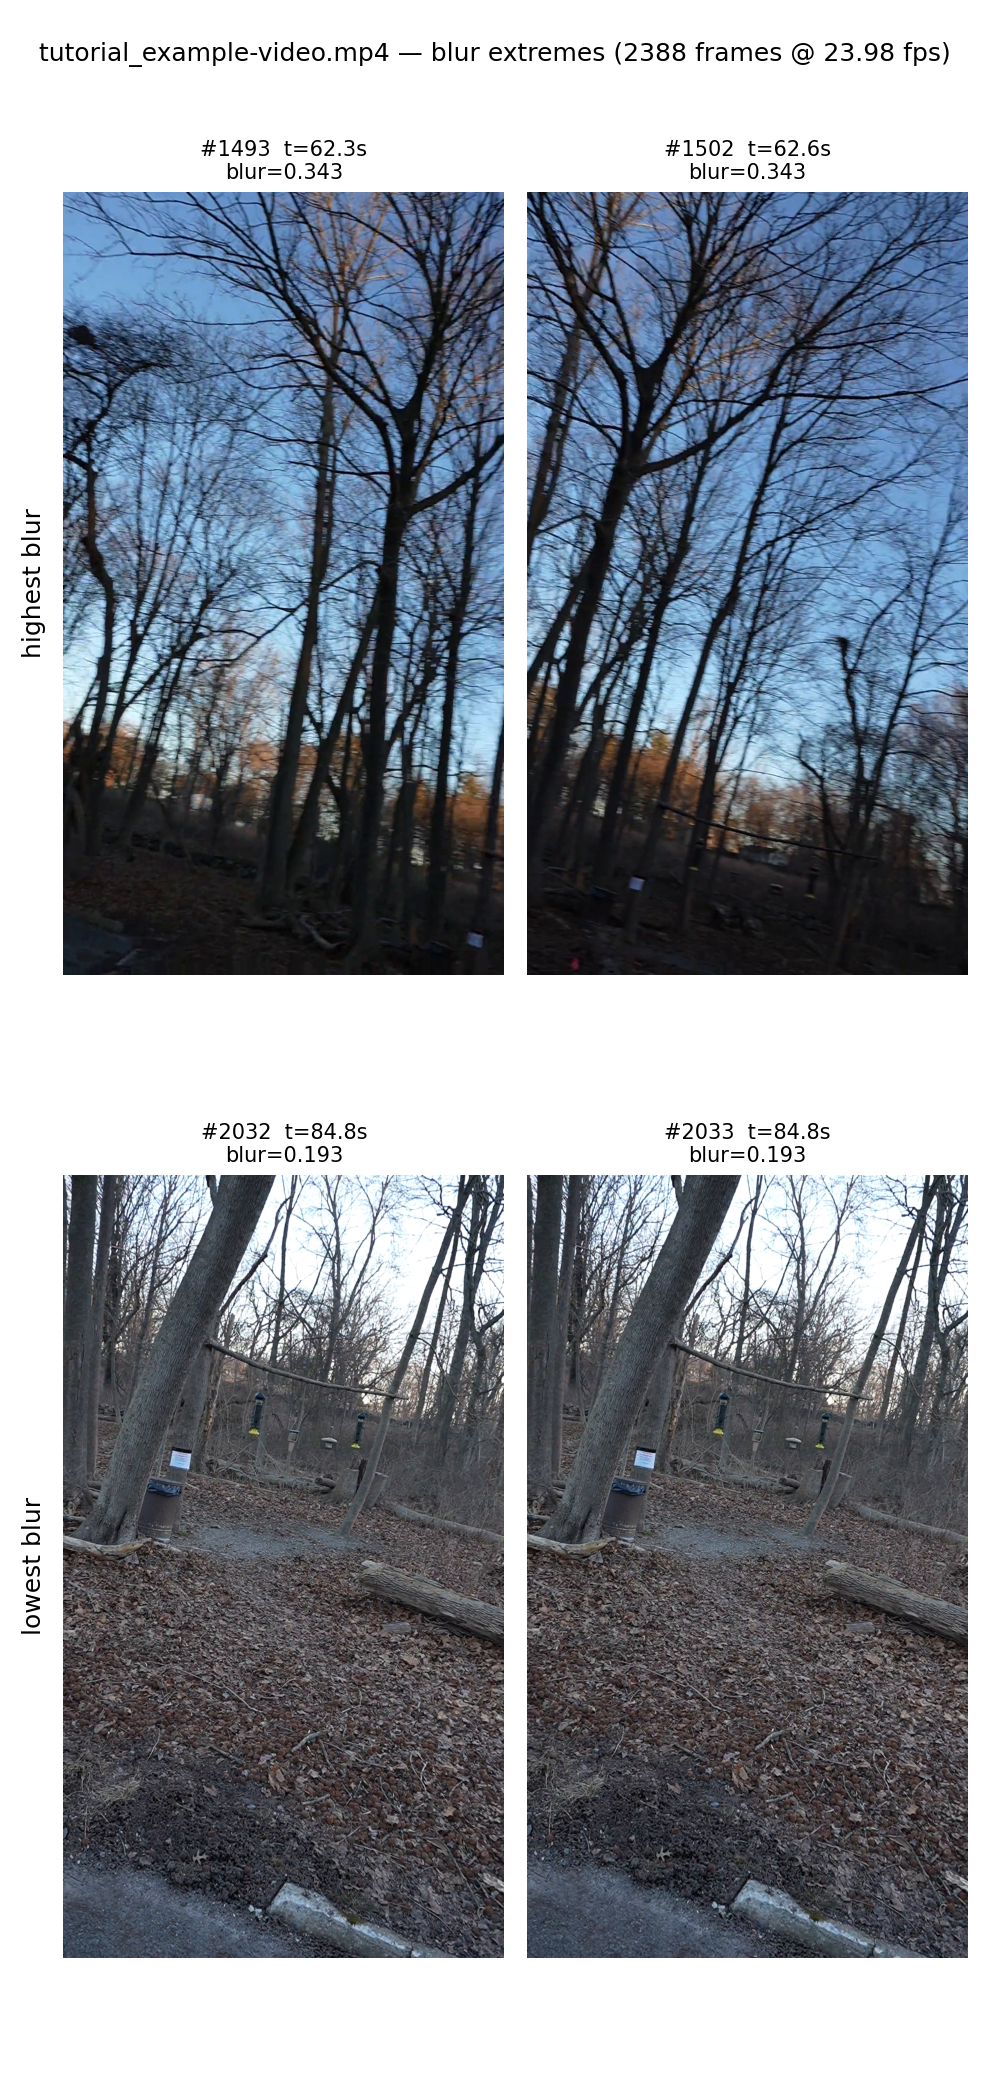

In [6]:
extremes_png = plot_frame_extremes(report, VIDEO_PATH, plots_dir, column="blur", n=2)
Image(filename=extremes_png)

Compare the top row with the bottom row to judge which blur values you would still accept.

## 2. Choosing keyframes

`filter_frame_quality` is the one place a frame is judged. It turns the report into a mask of
eligible frames using two thresholds from `preproc.quality`:

- `sharpness_k` is a robust z-score cut on `log(laplacian)`, computed per video. Sharpness is
  judged relative to the rest of the clip because laplacian variance depends on resolution,
  texture and content, so a fixed threshold does not transfer between videos. Larger keeps more.
- `max_clipped_frac` is an absolute ceiling on the fraction of pixels at 0 or 255. Those pixels
  recorded nothing that can be recovered.

Because judging is separate from measuring, you can change the thresholds without decoding the
video again.

In [7]:
preproc_cfg = scene.config["preproc"]
quality = preproc_cfg["quality"]
max_frames = preproc_cfg["max_frames"]

eligible = filter_frame_quality(report, **quality)
print(f"eligible: {eligible.sum()} / {eligible.size} frames")

eligible: 2041 / 2388 frames


Three samplers pick from that eligible pool. Each one rebuilds the pool from the same
thresholds and decodes only the frames it picks.

- `sample_fps` takes one frame every `1/fps` seconds, the sharpest eligible frame in each slot.
  It fixes the spacing between frames, so the baseline does not depend on clip length. It is the
  default in `configs/base.yaml`.
- `sample_uniform` takes exactly `max_frames` frames, evenly spaced over the eligible pool. Use
  it when you need an exact count.
- `sample_optical_flow` walks the video in order and keeps a frame once the camera has moved or
  turned enough since the last keyframe, so a slow pan yields fewer frames. It stops as soon as it
  has `max_frames`, so with a small budget it can cover only the start of the clip.

fps=2.000 wanted 199 frames, outside [min_frames=None, max_frames=96]; re-spread to 96 frames over the whole video (effective 0.964 fps)


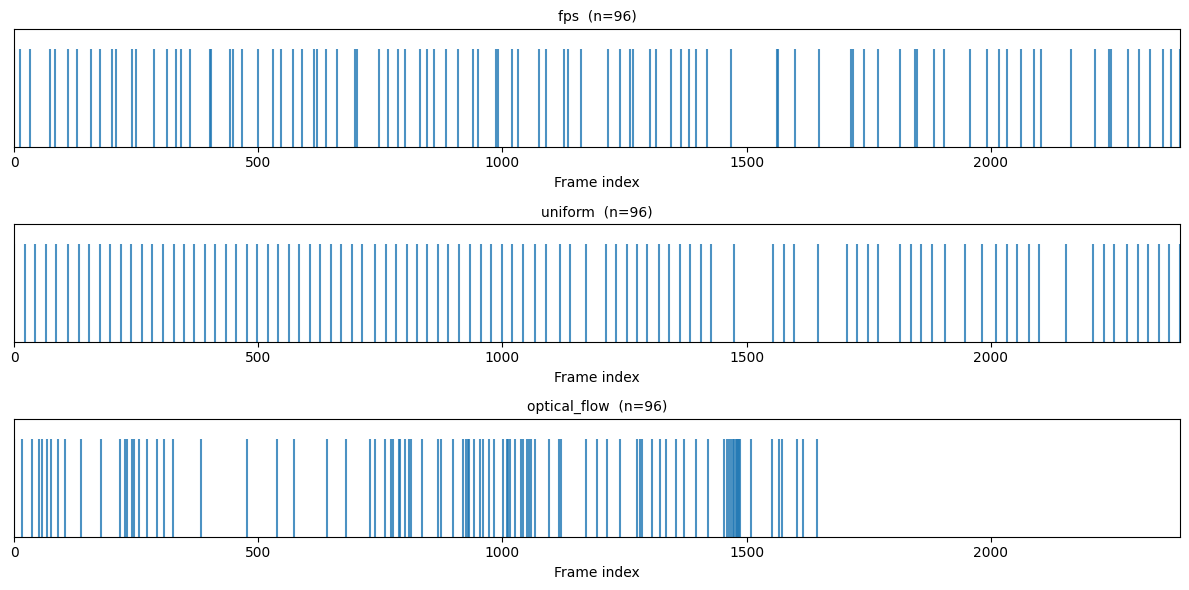

In [8]:
# Same quality gate and budget the stage used; only the records are kept
_, fps_records = sample_fps(
    str(VIDEO_PATH),
    fps=preproc_cfg["fps"],
    report=report,
    max_frames=max_frames,
    quality=quality,
    workers=preproc_cfg["n_workers"],
)
_, uniform_records = sample_uniform(
    str(VIDEO_PATH),
    max_frames=max_frames,
    report=report,
    quality=quality,
    workers=preproc_cfg["n_workers"],
)
_, flow_records = sample_optical_flow(
    str(VIDEO_PATH),
    report=report,
    max_frames=max_frames,
    quality=quality,
)

# Source frame index of each pick, one list per sampler
fps_idxs = [r["frame_idx"] for r in fps_records]
uniform_idxs = [r["frame_idx"] for r in uniform_records]
flow_idxs = [r["frame_idx"] for r in flow_records]

selections = {"fps": fps_idxs, "uniform": uniform_idxs, "optical_flow": flow_idxs}
plot_selection(eligible.size, selections)

Each line is one selected frame. Check whether a sampler spreads its picks across the whole
clip or bunches them where the camera moved.

## 3. The keyframe store

The stage wrote its picks to `scene.images_dir` as `frame_NNNNNN.png`, named by the frame's index
in the source video. The PNGs are lossless RGB, and every later stage reads its frames from this
folder.

96 keyframes in /workspace/collab-splats/.worktrees/tutorial-rework/data/tutorial_scene/images
first: frame_000000.png  last: frame_002387.png


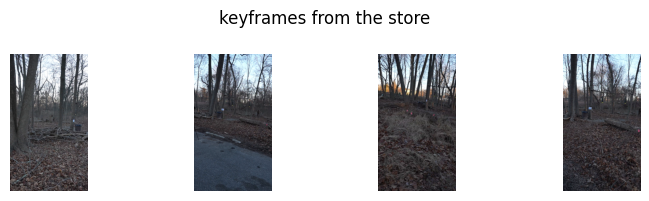

In [9]:
print(f"{len(stored)} keyframes in {scene.images_dir}")
print("first:", stored[0].name, " last:", stored[-1].name)

# Four keyframes spread across the store
step = len(kept) // 4
montage_idxs = kept[::step][:4]
montage = read_frames(scene.images_dir, montage_idxs)
plot_frame_grid(montage, title="keyframes from the store", n_cols=4)

Consecutive keyframes should overlap enough that the same surfaces appear in more than one
frame.

## 4. Lens distortion

Action-camera lenses bend straight lines, which hurts every stage that assumes a pinhole camera.
With `preproc.undistort: true` the stage fits the lens with a small SfM run on the keyframes,
then rewrites `images/` undistorted onto a pinhole framing; the default is `false`.

## In a pipeline run

The `preproc` stage does everything on this page in one call. These are the keys that control it,
with the values from `configs/base.yaml` (this scene sets `max_frames: 96`):

```yaml
preproc:
  frame_selection: fps        # fps | uniform | optical_flow
  fps: 2.0                    # fps only: samples per second
  max_frames: 300             # count for uniform, ceiling otherwise
  undistort: false            # self-calibrate, then rewrite images/ undistorted
  quality:
    sharpness_k: 2.0          # robust z-score cut on log(laplacian)
    max_clipped_frac: 0.25    # ceiling on the clipped-pixel fraction
```